In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Pour commencer, analysons la partie descriptives pour avoir une vision d'ensemble des exploitations saines et defaillantes.

In [6]:

train = pd.read_csv("farms_train.csv")
sains = train[train['DIFF'] == 1]
defaillantes = train[train['DIFF'] == 0]

print("=== Exploitations saines ===")
print(sains.describe())

print("\n=== Exploitations défaillantes ===")
print(defaillantes.describe())

=== Exploitations saines ===
        DIFF         TOF         AGE          R7          R8         R17  \
count  200.0  200.000000  200.000000  200.000000  200.000000  200.000000   
mean     1.0    2.225000   43.990000    0.485937    0.382352    0.055776   
std      0.0    1.149339    8.865828    0.305620    0.369150    0.022405   
min      1.0    1.000000   24.000000    0.051300    0.024290    0.020200   
25%      1.0    1.000000   37.750000    0.253000    0.126100    0.039375   
50%      1.0    2.000000   45.000000    0.461500    0.247550    0.053100   
75%      1.0    3.000000   49.250000    0.643000    0.550425    0.067000   
max      1.0    5.000000   62.000000    1.432000    1.849400    0.124000   

              R22         R32  
count  200.000000  200.000000  
mean     0.731740    0.326729  
std      1.154430    0.076160  
min      0.095740    0.001920  
25%      0.307450    0.275150  
50%      0.507950    0.331100  
75%      0.755275    0.383850  
max     13.673000    0.481600 

Pour continuer, voici la matrice de corrélation entre les variables. On observe que DIFF est corrélé à R32, R17 et R7. Comme DIFF est binaire (0/1), les corrélations entre DIFF et les variables continues sont en fait des corrélations point-bisériales, mathématiquement équivalentes à un Pearson classique, donc valides à interpréter. On lit : R32 (+0.62) → plus la rentabilité résiduelle est élevée, plus la probabilité d'être sain augmente ; R17 (-0.38) et R7 (-0.33) → plus l'endettement/son coût sont élevés, plus la probabilité de défaillance augmente. Les autres variables (AGE, R8, R22) proches de 0 ne montrent pas de lien linéaire avec DIFF.

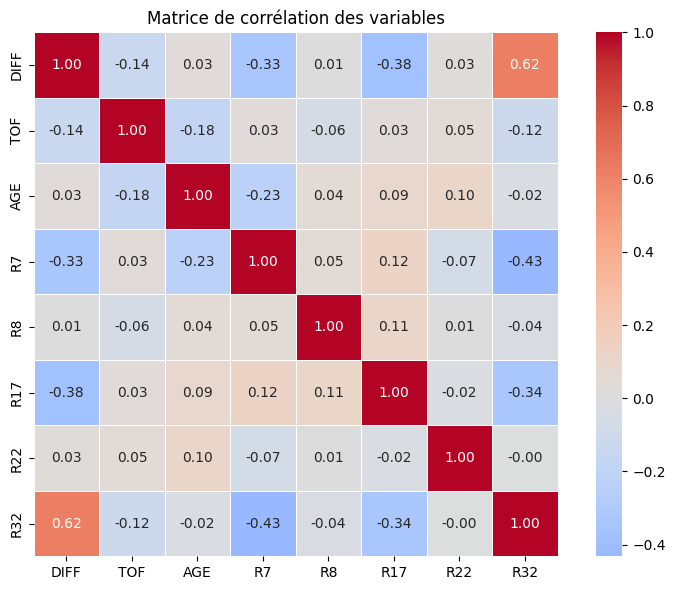

In [9]:
# Matrice de corrélation
corr = train.corr()

# Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=0.5)
plt.title("Matrice de corrélation des variables")
plt.tight_layout()
plt.show()

Les exploitations saines (1) ont un R32 nettement plus élevé (médiane ~0.33) que les défaillantes (0, médiane ~0.18), avec des boîtes qui se chevauchent peu. Les points hors moustaches sur le boxplot sont des outliers au sens statistique (calcul IQR), pas des erreurs de saisie. Pour R32, ce sont des valeurs négatives, toutes côté DIFF=0 : logique, un R32 négatif signifie que l'EBITDA ne couvre pas les charges financières, typique d'une exploitation en difficulté. Ce sont donc de vraies observations informatives, à garder telles quelles.

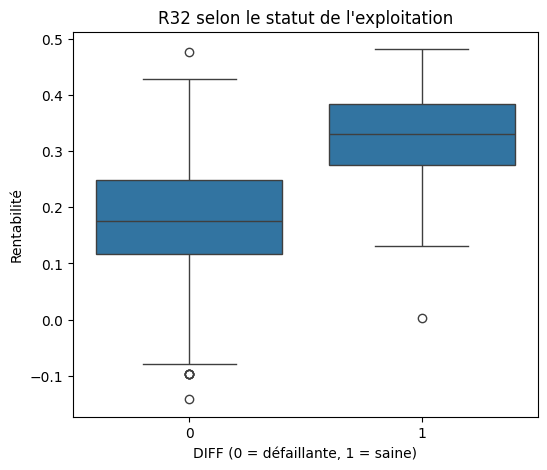

In [24]:
plt.figure(figsize=(6,5))
sns.boxplot(x='DIFF', y='R32', data=train)
plt.title("R32 selon le statut de l'exploitation")
plt.xlabel("DIFF (0 = défaillante, 1 = saine)")
plt.ylabel("Rentabilité")

plt.show()

Ce nuage de points montre R32 pour chaque exploitation (index en abscisse), coloré selon DIFF. Les points verts (exploitations saines) se concentrent surtout entre 0.25 et 0.45, tandis que les points rouges (défaillantes) se répartissent plus bas, entre -0.15 et 0.30. On observe une tendance claire : plus la rentabilité R32 est élevée, plus l'exploitation est susceptible d'être saine.

Il existe toutefois une zone de chevauchement notable entre 0.15 et 0.30, où rouges et verts se mélangent — R32 seul ne permet donc pas une séparation parfaite entre les deux classes. Les valeurs négatives, toutes rouges, correspondent aux outliers déjà identifiés (EBITDA insuffisant pour couvrir les charges financières), cohérents avec des cas de défaillance sévère. Nos modèles auront besoin de plus variables explicatives comme le R17 et le R7 sous peines de faire des erreurs.


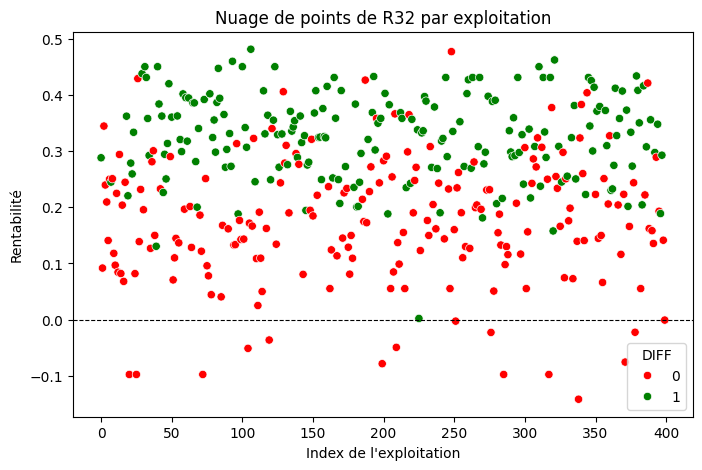

In [23]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=train.index, y='R32', hue='DIFF', data=train, palette=['red','green'])
plt.axhline(0, color='black', linestyle='--', linewidth=0.8)
plt.title("Nuage de points de R32 par exploitation")
plt.xlabel("Index de l'exploitation")
plt.ylabel("Rentabilité")
plt.legend(title='DIFF')
plt.show()

Les points verts (saines) se concentrent en haut à gauche : R17 faible (peu de charges financières relatives à la dette) et R32 élevé (bonne rentabilité ). Les points rouges (défaillantes) se répartissent plutôt en bas à droite : R17 plus élevé et R32 plus faible, voire négatif. On observe une diagonale de séparation assez nette : quand R17 augmente, R32 a tendance à diminuer, et les rouges dominent de plus en plus.

La zone de chevauchement (autour de R17 entre 0.04-0.08 et R32 entre 0.2-0.35) reste présente mais plus restreinte que sur le nuage univarié de R32 seul,la combinaison des deux variables sépare donc mieux les classes qu'une seule variable prise isolément.

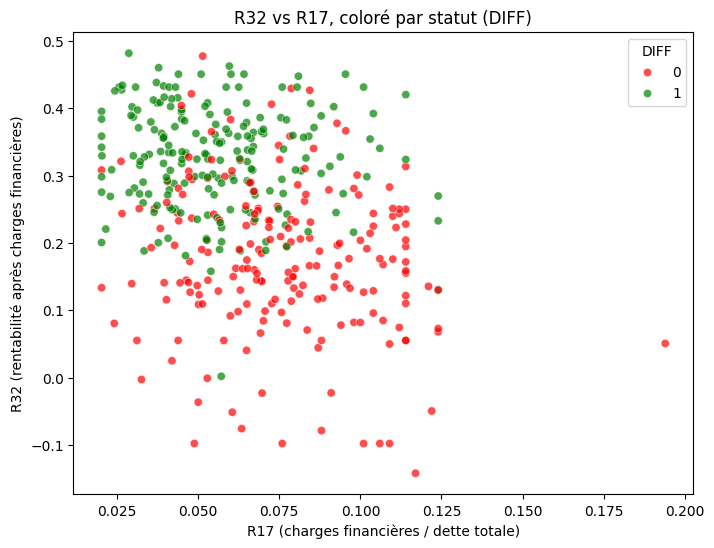

In [13]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='R17', y='R32', hue='DIFF', data=train, palette=['red','green'], alpha=0.7)
plt.title("R32 vs R17, coloré par statut (DIFF)")
plt.xlabel("R17 (charges financières / dette totale)")
plt.ylabel("R32 (rentabilité après charges financières)")
plt.legend(title='DIFF')
plt.show()

Ce graphique confirme la même logique : les exploitations saines (vert) se concentrent surtout à gauche, avec un R7 faible (peu de dette long/moyen terme par rapport à leur activité) et un R32 élevé — elles ne se sont pas trop endettées et restent rentables. Les exploitations défaillantes (rouge) se dispersent beaucoup plus largement vers la droite (dette élevée) et vers le bas (rentabilité faible, voire négative), certaines allant jusqu'à un R7 de 3, un niveau d'endettement extrême par rapport au reste de l'échantillon.


Mais contrairement à R17 vs R32, la séparation est moins nette : une grosse zone de chevauchement subsiste entre R7 = 0 et 1, où saines et défaillantes sont très mélangées. Autrement dit, avoir peu de dette (R7 faible) ne garantit pas d'être sain,beaucoup de défaillantes ont aussi un R7 faible, ce qui veut dire que leur problème financier ne vient pas forcément du volume de dette lui-même, mais possiblement d'autre chose (le coût de cette dette, R17, ou une rentabilité déjà fragile indépendamment de l'endettement).

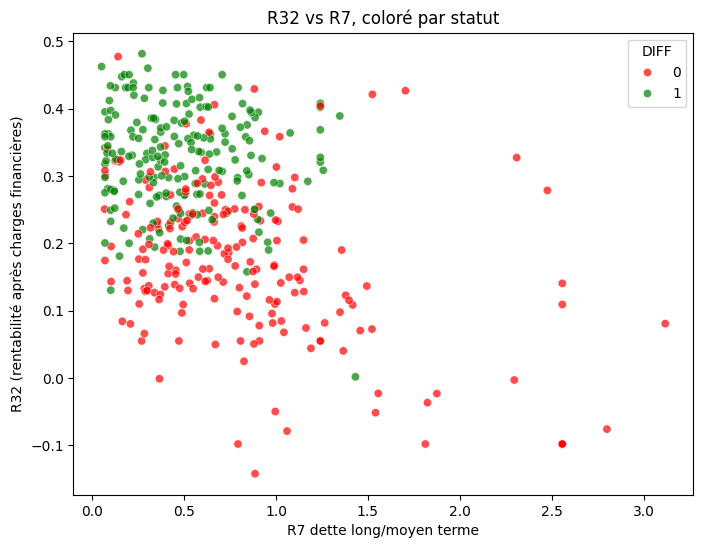

In [22]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='R7', y='R32', hue='DIFF', data=train, palette=['red','green'], alpha=0.7)
plt.title("R32 vs R7, coloré par statut")
plt.xlabel("R7 dette long/moyen terme")
plt.ylabel("R32 (rentabilité après charges financières)")
plt.show()

L'exploration des données a permis de mettre en évidence les variables les plus pertinentes pour distinguer les exploitations agricoles saines des exploitations défaillantes. Parmi les 7 variables disponibles, trois ratios financiers se démarquent nettement : R32 (rentabilité), avec la corrélation la plus forte à DIFF (+0.62), suivi de R17 (coût de la dette, -0.38) et R7 (niveau d'endettement, -0.33).

L'analyse par nuages de points a confirmé que ces variables séparent bien les deux groupes en tendance, mais avec un chevauchement non négligeable lorsqu'elles sont prises isolément, la combinaison de R32 et R17 réduit significativement cette zone de confusion, ce qui suggère qu'une approche multivariée sera nécessaire plutôt qu'une simple règle sur une seule variable.

Les variables AGE, R8, R22 et TOF n'ont, elles, pas montré de lien linéaire marqué avec la variable cible, sans pour autant être écartées définitivement : leur éventuel apport (effets non-linéaires ou interactions) devra être vérifié directement à travers les performances des modèles de classification, mesurées par l'AUC.